# Fine-Tuning BERT for Disaster Tweet Classification
## Comparing Logistic Regression, BERT, and BERTweet on the HumAID Dataset

**Dataset:** HumAID (QCRI), ~77K tweets from real disasters labeled into 10 humanitarian categories
**Supplementary data:** CrisisBench, ~87K additional English crisis tweets merged into training set (V3)

**Goal:** Compare three text classification approaches: TF-IDF + Logistic Regression, fine-tuned BERT, and fine-tuned BERTweet. Evaluate on accuracy, Top-2 accuracy, weighted F1, and training cost.

**Environment:** Google Colab with T4 GPU

**Reference:** Alam et al., "HumAID: Human-Annotated Disaster Incidents Data from Twitter" (ICWSM 2021)

---
## 1. Setup and Installs

Install the libraries that aren't pre-installed in Colab and check that the GPU is available.

We need two HuggingFace libraries:
- **`datasets`** to download HumAID directly from HuggingFace Hub
- **`transformers`** to load the pre-trained BERT model and tokenizer

We set `device = "cuda"` so computation runs on the GPU. BERT has ~110 million parameters, so training on CPU would be way too slow.

In [1]:
!pip install -q datasets transformers seaborn emoji

# Verify GPU is available before proceeding
import torch
assert torch.cuda.is_available(), "ERROR: No GPU detected! Go to Runtime → Change runtime type → GPU"
print(f"GPU ready: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")


GPU ready: NVIDIA L4 (23.7 GB)

In [2]:
from huggingface_hub import login
login()  # Paste your HuggingFace token when prompted

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import copy
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Visual style — clean, minimal aesthetic
sns.set_style("white")
plt.rcParams.update({
    'figure.facecolor': '#F0F3F1',
    'axes.facecolor': '#F0F3F1',
    'figure.dpi': 120,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#2D2D2D',
    'axes.labelsize': 11,
    'axes.labelcolor': '#555555',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.color': '#777777',
    'ytick.color': '#777777',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC',
    'grid.color': '#D8E0DC',
    'grid.alpha': 0.5,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
})

# Color palette for all charts (consistent across notebook)
COLORS = {
    'primary': '#5A8A7A',     # dusty teal
    'secondary': '#A3C4B8',   # light sage
    'dark': '#2D3436',        # dark slate
    'neutral': '#A0A0A0',     # warm gray
    'danger': '#B85450',      # muted red
    'success': '#5B8266',     # sage green
    'logreg': '#5A8A7A',      # teal (Model 1)
    'bert': '#2D3436',        # dark slate (Model 2)
    'bertweet': '#A3C4B8',    # light sage (Model 3)
}

# Set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB

---
## 2. Load the Dataset

HumAID comes from HuggingFace with pre-defined train, validation, and test splits.

- **Train set** is used to train both models
- **Validation set** is used during BERT training to check for overfitting
- **Test set** is for final evaluation only. Neither model sees this during training.

We need the validation split because BERT is a very large model (~110M parameters) on a relatively small dataset. Without monitoring validation loss, we can't tell if it's learning or just memorizing.

In [4]:
from datasets import DatasetDict, load_dataset

# Load the dataset using verification_mode to skip the check for the missing 'dev' split
humaid_dataset = load_dataset("QCRI/HumAID-all", verification_mode="no_checks")

print(humaid_dataset)
print(f"\nTrain size:      {len(humaid_dataset['train']):,}")

# Safely check for validation/dev splits
if 'validation' in humaid_dataset:
    print(f"Validation size: {len(humaid_dataset['validation']):,}")
elif 'dev' in humaid_dataset:
    print(f"Validation size: {len(humaid_dataset['dev']):,}")
else:
    print("Validation split not found!")

print(f"Test size:       {len(humaid_dataset['test']):,}")

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})

Train size:      53,531
Validation size: 7,793
Test size:       15,160

In [5]:
# Look at a few examples to understand the data
print("Column names:", humaid_dataset['train'].column_names)
print("\nFeatures:", humaid_dataset['train'].features)
print("\n--- Sample tweets ---")
for i in range(3):
    print(f"\nTweet: {humaid_dataset['train'][i]['tweet_text']}")
    print(f"Label: {humaid_dataset['train'][i]['class_label']}")

Column names: ['tweet_text', 'class_label']

Features: {'tweet_text': Value('string'), 'class_label': Value('string')}

--- Sample tweets ---

Tweet: Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un
Label: injured_or_dead_people

Tweet: Im at awe and saddened with the #EcuadorEarthquake Please any donations can help the most unfortunate!
Label: rescue_volunteering_or_donation_effort

Tweet: RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these earthquakes. :( This is has been a terr
Label: sympathy_and_support

---
## 2b. Merge External Data (CrisisBench) - V3

V2 showed that the rarest class (`missing_or_found_people`) has only ~200 training examples. That's not enough for a 110M-parameter model. To fix this, we merge additional labeled crisis tweets from **CrisisBench** (Alam et al., 2021), a benchmark of 8 crisis tweet datasets from the same research group (QCRI) that created HumAID.

**Important:** We only add CrisisBench data to the **training set**. Validation and test sets stay HumAID-only so we can still compare fairly with V2 results and the original paper.

In [6]:
# Load CrisisBench humanitarian dataset
crisisbench = load_dataset("QCRI/CrisisBench-all-lang", "humanitarian", verification_mode="no_checks")

print("CrisisBench splits:")
for split in crisisbench:
    print(f"  {split}: {len(crisisbench[split]):,} rows")

print(f"\nColumns: {crisisbench['train'].column_names}")

# Show sample tweets
print("\n--- Sample CrisisBench tweets ---")
for i in range(3):
    row = crisisbench['train'][i]
    print(f"\nText: {row['text'][:150]}")
    print(f"Label: {row['class_label']}  |  Lang: {row['lang']}  |  Source: {row['source']}")

CrisisBench splits:
  test: 28,024 rows
  dev: 14,436 rows
  train: 99,073 rows

Columns: ['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label']

--- Sample CrisisBench tweets ---

Text: Anche questa volta è durata tanto..anche molto forte.. #Terremoto #Italia
Label: other_relevant_information  |  Lang: it  |  Source: crisislext26

Text: Approximately 100km long firebreaks have been constructed by Indonesia and elsewhere.
Label: infrastructure_and_utilities_damage  |  Lang: en  |  Source: drd-figureeight-multimedia

Text: God bless you... https://t.co/AnEy1ydkkz
Label: not_humanitarian  |  Lang: en  |  Source: crisisnlp-volunteers

In [7]:
# Step 1: Filter to English tweets only
cb_english = crisisbench['train'].filter(lambda x: x['lang'] == 'en')
print(f"English tweets: {len(cb_english):,} / {len(crisisbench['train']):,} ({100*len(cb_english)/len(crisisbench['train']):.1f}%)")

# Step 2: Define the label mapping from CrisisBench → HumAID
cb_to_humaid_labels = {
    'missing_and_found_people': 'missing_or_found_people',
    'displaced_and_evacuations': 'displaced_people_and_evacuations',
    'infrastructure_and_utilities_damage': 'infrastructure_and_utility_damage',
    'donation_and_volunteering': 'rescue_volunteering_or_donation_effort',
    'requests_or_needs': 'requests_or_urgent_needs',
    'caution_and_advice': 'caution_and_advice',
    'injured_or_dead_people': 'injured_or_dead_people',
    'not_humanitarian': 'not_humanitarian',
    'other_relevant_information': 'other_relevant_information',
    'sympathy_and_support': 'sympathy_and_support',
}

# Step 3: Keep only tweets whose category exists in HumAID
cb_matching = cb_english.filter(lambda x: x['class_label'] in cb_to_humaid_labels)
print(f"Matching categories: {len(cb_matching):,} / {len(cb_english):,} (dropped {len(cb_english) - len(cb_matching):,} tweets from 6 extra categories)")

# Show what we dropped
from collections import Counter
dropped_labels = Counter([row['class_label'] for row in cb_english if row['class_label'] not in cb_to_humaid_labels])
print(f"\nDropped categories:")
for label, count in sorted(dropped_labels.items(), key=lambda x: -x[1]):
    print(f"  {label}: {count}")

English tweets: 92,757 / 99,073 (93.6%)

Matching categories: 87,496 / 92,757 (dropped 5,261 tweets from 6 extra categories)

Dropped categories:
  affected_individual: 2454
  disease_related: 1033
  response_efforts: 780
  personal_update: 728
  physical_landslide: 255
  terrorism_related: 11

In [8]:
# Step 4: Map CrisisBench labels to HumAID labels
cb_tweets = [row['text'] for row in cb_matching]
cb_labels = [cb_to_humaid_labels[row['class_label']] for row in cb_matching]

# Step 5: Get original HumAID training data
humaid_train_tweets = list(humaid_dataset['train']['tweet_text'])
humaid_train_labels = list(humaid_dataset['train']['class_label'])

print(f"HumAID training tweets:     {len(humaid_train_tweets):,}")
print(f"CrisisBench tweets to add:  {len(cb_tweets):,}")

# Step 6: Merge — append CrisisBench to HumAID training data
merged_train_tweets = humaid_train_tweets + cb_tweets
merged_train_labels = humaid_train_labels + cb_labels

print(f"Merged training set:        {len(merged_train_tweets):,}")
print(f"\nValidation set (HumAID only): {len(humaid_dataset['validation']):,}")
print(f"Test set (HumAID only):       {len(humaid_dataset['test']):,}")

HumAID training tweets:     53,531
CrisisBench tweets to add:  87,496
Merged training set:        141,027

Validation set (HumAID only): 7,793
Test set (HumAID only):       15,160

In [11]:
# Compare class distributions: HumAID-only vs Merged
humaid_dist = Counter(humaid_train_labels)
merged_dist = Counter(merged_train_labels)

print(f"{'Category':<45} {'HumAID':>8} {'Merged':>8} {'Added':>8} {'Ratio':>8}")
print('-' * 85)
for cat in sorted(merged_dist.keys()):
    h_count = humaid_dist.get(cat, 0)
    m_count = merged_dist.get(cat, 0)
    added = m_count - h_count
    ratio = f"{m_count/h_count:.1f}x" if h_count > 0 else 'N/A'
    print(f"  {cat:<43} {h_count:>8,} {m_count:>8,} {added:>+8,} {ratio:>8}")

print(f"\n  {'TOTAL':<43} {sum(humaid_dist.values()):>8,} {sum(merged_dist.values()):>8,} {sum(merged_dist.values())-sum(humaid_dist.values()):>+8,}")

# Show the imbalance ratio
max_class = max(merged_dist.values())
min_class = min(merged_dist.values())
max_name = [k for k,v in merged_dist.items() if v == max_class][0]
min_name = [k for k,v in merged_dist.items() if v == min_class][0]
print(f"\nImbalance ratio: {max_class:,} / {min_class:,} = {max_class/min_class:.0f}:1")
print(f"  Largest:  {max_name} ({max_class:,})")
print(f"  Smallest: {min_name} ({min_class:,})")
print(f"\nNote: Even after merging, the imbalance INCREASED from ~60:1 to ~{max_class//min_class}:1.")
print("This confirms that rare classes are structurally rare in disaster tweet data.")


Category                                        HumAID   Merged    Added    Ratio
-------------------------------------------------------------------------------------
  caution_and_advice                             3,774    5,875   +2,101     1.6x
  displaced_people_and_evacuations               2,800    3,159     +359     1.1x
  infrastructure_and_utility_damage              5,715    9,256   +3,541     1.6x
  injured_or_dead_people                         5,110    7,055   +1,945     1.4x
  missing_or_found_people                          250      623     +373     2.5x
  not_humanitarian                               4,407   40,516  +36,109     9.2x
  other_relevant_information                     8,501   37,996  +29,495     4.5x
  requests_or_urgent_needs                       1,833    6,673   +4,840     3.6x
  rescue_volunteering_or_donation_effort        14,891   20,075   +5,184     1.3x
  sympathy_and_support                           6,250    9,799   +3,549     1.6x

  TOTAL    

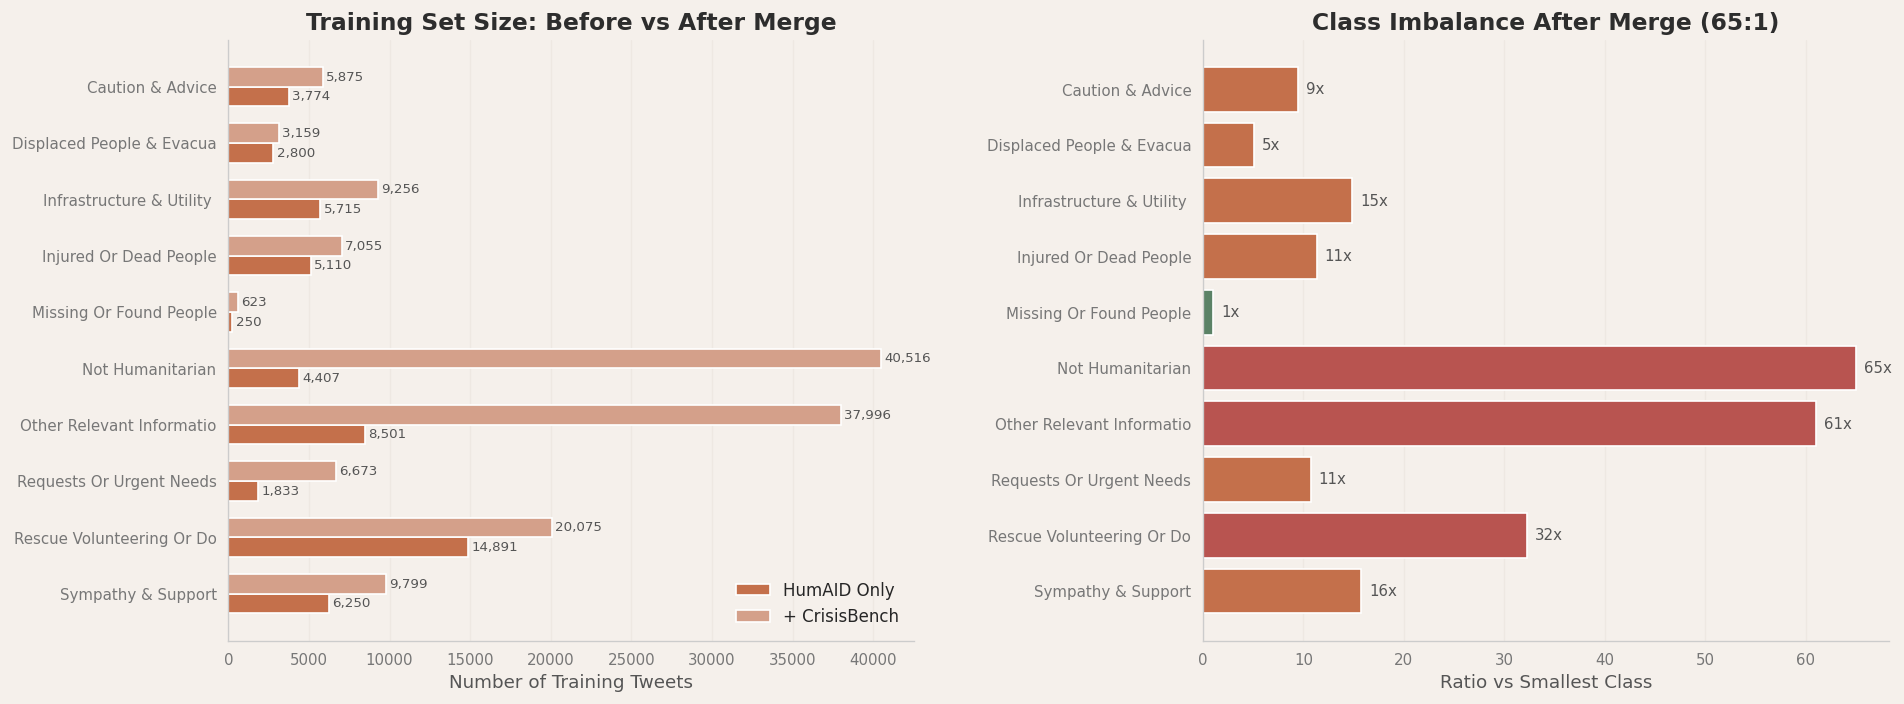

Note: Even after merging, the imbalance INCREASED from ~60:1 to ~65:1.
This confirms that rare classes are structurally rare in disaster tweet data.

In [20]:
# Visual: HumAID-only vs Merged training set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

categories = sorted(merged_dist.keys())
short_names = [name.replace('_', ' ').replace(' and ', ' & ').title()[:25] for name in categories]
humaid_counts = [humaid_dist.get(cat, 0) for cat in categories]
merged_counts = [merged_dist.get(cat, 0) for cat in categories]

# Left: Side-by-side horizontal bars
x = np.arange(len(categories))
width = 0.35
ax1.barh(x + width/2, humaid_counts, width, label='HumAID Only', color=COLORS['primary'])
ax1.barh(x - width/2, merged_counts, width, label='+ CrisisBench', color=COLORS['secondary'])
for i in range(len(categories)):
    ax1.text(merged_counts[i] + 200, x[i] - width/2, f'{merged_counts[i]:,}', va='center', fontsize=8,
color='#555555')
    ax1.text(humaid_counts[i] + 200, x[i] + width/2, f'{humaid_counts[i]:,}', va='center', fontsize=8,
color='#555555')
ax1.set_yticks(x)
ax1.set_yticklabels(short_names, fontsize=9)
ax1.set_xlabel('Number of Training Tweets')
ax1.set_title('Training Set Size: Before vs After Merge')
ax1.legend(loc='lower right')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Right: Imbalance ratio
ratios = [merged_dist[cat] / min(merged_dist.values()) for cat in categories]
bar_colors = [COLORS['danger'] if r > 20 else COLORS['primary'] if r > 5 else COLORS['success'] for r in
ratios]
bars = ax2.barh(x, ratios, color=bar_colors)
for i, r in enumerate(ratios):
    ax2.text(r + 0.8, i, f'{r:.0f}x', va='center', fontsize=9, color='#555555')
ax2.set_yticks(x)
ax2.set_yticklabels(short_names, fontsize=9)
ax2.set_xlabel('Ratio vs Smallest Class')
ax2.set_title('Class Imbalance After Merge (65:1)')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout(w_pad=3)
plt.show()
print(f"\nNote: Even after merging, the imbalance INCREASED from ~60:1 to ~{max_class//min_class}:1.")
print("This confirms that rare classes are structurally rare in disaster tweet data.")


---
## 3. Exploratory Data Analysis

Before building any model, two things to check:

1. **Class distribution.** Are the 10 categories balanced? If not, accuracy alone is misleading (the model could just predict the most common class). This is why we use weighted F1.

2. **What the tweets look like.** Reading examples from each class helps understand what the model needs to learn, and later helps interpret why some categories are harder.

In [21]:
# Get the humanitarian category names from ALL splits
category_names = sorted(set(
    humaid_dataset['train'].unique('class_label') +
    humaid_dataset['validation'].unique('class_label') +
    humaid_dataset['test'].unique('class_label')
))
num_categories = len(category_names)
category_to_id = {name: i for i, name in enumerate(category_names)}

print(f"Number of categories: {num_categories}")
print(f"\nCategory names:")
for i, name in enumerate(category_names):
    print(f"  {i}: {name}")

Number of categories: 10

Category names:
  0: caution_and_advice
  1: displaced_people_and_evacuations
  2: infrastructure_and_utility_damage
  3: injured_or_dead_people
  4: missing_or_found_people
  5: not_humanitarian
  6: other_relevant_information
  7: requests_or_urgent_needs
  8: rescue_volunteering_or_donation_effort
  9: sympathy_and_support

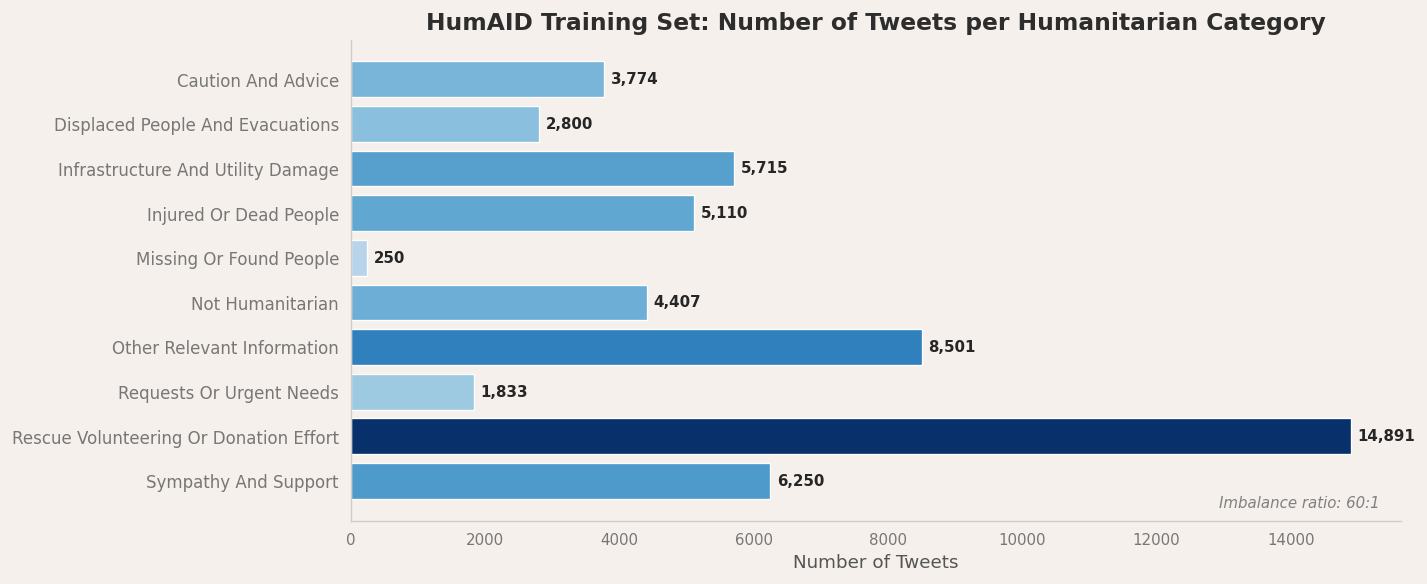

In [22]:
# Class distribution in training set
train_category_ids = [category_to_id[label] for label in humaid_dataset['train']['class_label']]
category_counts = pd.Series(train_category_ids).value_counts().sort_index()
counts_list = [category_counts.get(i, 0) for i in range(num_categories)]

# Format category names for display (replace underscores, title case)
display_names = [name.replace('_', ' ').title() for name in category_names]

fig, ax = plt.subplots(figsize=(12, 5))

# Color bars by frequency — gradient from light to dark
norm = plt.Normalize(min(counts_list), max(counts_list))
bar_colors = plt.cm.Blues(norm(counts_list) * 0.7 + 0.3)

bars = ax.barh(range(num_categories), counts_list, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(num_categories))
ax.set_yticklabels(display_names, fontsize=10)
ax.set_xlabel('Number of Tweets')
ax.set_title('HumAID Training Set: Number of Tweets per Humanitarian Category', fontweight='bold')
ax.invert_yaxis()

# Add count labels on bars
for bar, count in zip(bars, counts_list):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9, fontweight='bold')

# Add imbalance annotation
max_count = max(counts_list)
min_count = min(counts_list)
ax.text(0.98, 0.02, f'Imbalance ratio: {max_count/min_count:.0f}:1',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

In [23]:
# Sample one tweet per category
print("--- One sample tweet per category ---\n")
train_tweets_df = pd.DataFrame(humaid_dataset['train'])
train_tweets_df['category_id'] = train_tweets_df['class_label'].map(category_to_id)
for category_id in range(num_categories):
    sample = train_tweets_df[train_tweets_df['category_id'] == category_id].iloc[0]
    print(f"[{category_names[category_id]}]")
    print(f"  \"{sample['tweet_text'][:150]}...\"" if len(sample['tweet_text']) > 150 else f"  \"{sample['tweet_text']}\"")
    print()

--- One sample tweet per category ---

[caution_and_advice]
  "Terrifying moment 7 8 magnitude earthquake strikes in Ecuador Daily Mail Online:  via @YouTube"

[displaced_people_and_evacuations]
  "Red Cross distributes $30M to Fort McMurray wildfire evacuees in 1 day"

[infrastructure_and_utility_damage]
  "RT @pzf: BREAKING PHOTOS: Major damage reported in Ecuador after massive earthquake."

[injured_or_dead_people]
  "Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un"

[missing_or_found_people]
  "Man still missing after Maryland flash flood. Two floods in two years in Ellicott City have residents wondering whether to rebuild.  #flooding #Maryla..."

[not_humanitarian]
  "@rickygervais Since you mention Ecuador in your new show, you should help people there. There was an earthquake on Saturday. Dont be a cunt"

[other_relevant_information]
  "RT Lucho_teleSUR: Ecuador continues to experience aftershocks, over 200 according

---
## 4. Preprocessing for Baseline (TF-IDF)

For logistic regression, we convert tweets to numerical vectors using **TF-IDF** (Term Frequency - Inverse Document Frequency).

Each tweet becomes a vector where each dimension represents a word. The value is weighted by how useful that word is for distinguishing documents. Common words like "the" get low scores; words like "earthquake" or "evacuation" get high scores because they appear in fewer documents.

TF-IDF treats each tweet as a bag of words and ignores word order. "not damaged" and "damaged" look nearly identical. This is where BERT does better.

We fit the TF-IDF vocabulary on the training set only, then transform all splits with that vocabulary. This prevents data leakage.

**Preprocessing step:** Before vectorizing, we clean the tweets by removing RT prefixes, @mentions, URLs, and hashtag symbols. These are Twitter noise that doesn't help classification.

In [24]:
def clean_tweet(text):
    """Remove Twitter-specific noise that doesn't help classification."""
    text = re.sub(r'RT @\w+:?\s*', '', text)   # Remove RT @user prefixes
    text = re.sub(r'@\w+', '', text)             # Remove @mentions
    text = re.sub(r'https?://\S+', '', text)     # Remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)         # Remove # symbol but keep the word
    text = re.sub(r'\s+', ' ', text)              # Collapse multiple spaces
    return text.strip()

# --- V3: Use MERGED training data (HumAID + CrisisBench) ---
train_tweets_raw = merged_train_tweets  # From cell above
val_tweets_raw = list(humaid_dataset['validation']['tweet_text'])   # HumAID only
test_tweets_raw = list(humaid_dataset['test']['tweet_text'])        # HumAID only

# Apply preprocessing to all splits
train_tweets = [clean_tweet(t) for t in train_tweets_raw]
val_tweets = [clean_tweet(t) for t in val_tweets_raw]
test_tweets = [clean_tweet(t) for t in test_tweets_raw]

# --- V3: Use MERGED labels for training ---
train_categories = [category_to_id[label] for label in merged_train_labels]
val_categories = [category_to_id[label] for label in humaid_dataset['validation']['class_label']]  # HumAID only
test_categories = [category_to_id[label] for label in humaid_dataset['test']['class_label']]        # HumAID only

print(f"Training tweets (merged):  {len(train_tweets):,}")
print(f"Validation tweets (HumAID): {len(val_tweets):,}")
print(f"Test tweets (HumAID):       {len(test_tweets):,}")

# Show before/after preprocessing examples
print("\n--- Preprocessing examples ---")
for i in range(3):
    print(f"\nBefore: \"{train_tweets_raw[i][:100]}\"")
    print(f"After:  \"{train_tweets[i][:100]}\"")

Training tweets (merged):  141,027
Validation tweets (HumAID): 7,793
Test tweets (HumAID):       15,160

--- Preprocessing examples ---

Before: "Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people "
After:  "Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people "

Before: "Im at awe and saddened with the #EcuadorEarthquake Please any donations can help the most unfortunat"
After:  "Im at awe and saddened with the EcuadorEarthquake Please any donations can help the most unfortunate"

Before: "RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these e"
After:  "Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these earthquakes. :( Thi"

In [26]:
# Fit TF-IDF on cleaned MERGED training tweets, transform all splits
tfidf_vectorizer = TfidfVectorizer(max_features=50000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(train_tweets)
X_val_tfidf = tfidf_vectorizer.transform(val_tweets)
X_test_tfidf = tfidf_vectorizer.transform(test_tweets)

y_train = np.array(train_categories)
y_val = np.array(val_categories)
y_test = np.array(test_categories)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}  (merged)")
print(f"Val matrix shape:   {X_val_tfidf.shape}  (HumAID only)")
print(f"Test matrix shape:  {X_test_tfidf.shape}  (HumAID only)")

TF-IDF vocabulary size: 50,000
Train matrix shape: (141027, 50000)  (merged)
Val matrix shape:   (7793, 50000)  (HumAID only)
Test matrix shape:  (15160, 50000)  (HumAID only)

---
## 5. Logistic Regression Baseline

Logistic regression with softmax over 10 classes. It learns a weight for every TF-IDF feature for every class. If "donations" has a high weight for "rescue, volunteering, or donation effort", tweets with that word get pushed toward that prediction.

We use scikit-learn's implementation and time training and inference separately so we can compare to BERT later. We also compute **Top-2 accuracy** (whether the correct label is in the model's top 2 predictions) since many disaster tweets are genuinely ambiguous between categories.

This is the baseline to see if BERT is even worth it. If logistic regression gets 95% F1, there's no point using a 110-million-parameter model.

In [27]:
# Train logistic regression
logreg_model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', n_jobs=-1)

print("Training Logistic Regression...")
logreg_train_start = time.time()
logreg_model.fit(X_train_tfidf, y_train)
logreg_train_time = time.time() - logreg_train_start
print(f"Training time: {logreg_train_time:.2f} seconds")

# Inference on test set
logreg_infer_start = time.time()
logreg_predictions = logreg_model.predict(X_test_tfidf)
logreg_infer_time = time.time() - logreg_infer_start
print(f"Inference time: {logreg_infer_time:.2f} seconds")

# Metrics
logreg_accuracy = accuracy_score(y_test, logreg_predictions)
logreg_weighted_f1 = f1_score(y_test, logreg_predictions, average='weighted')

# Top-2 accuracy: correct if true label is in the model's top 2 predictions
logreg_proba = logreg_model.predict_proba(X_test_tfidf)
logreg_top2 = np.argsort(logreg_proba, axis=1)[:, -2:]  # top 2 predicted classes
logreg_top2_correct = np.array([y_test[i] in logreg_top2[i] for i in range(len(y_test))])
logreg_top2_accuracy = logreg_top2_correct.mean()

print(f"\n--- Logistic Regression Results ---")
print(f"Accuracy:         {logreg_accuracy:.4f}")
print(f"Top-2 Accuracy:   {logreg_top2_accuracy:.4f}")
print(f"Weighted F1:      {logreg_weighted_f1:.4f}")


Training Logistic Regression...
Training time: 29.52 seconds
Inference time: 0.00 seconds

--- Logistic Regression Results ---
Accuracy:         0.7196
Top-2 Accuracy:   0.8854
Weighted F1:      0.7205

In [28]:
# Per-class report for logistic regression
print("\n--- Logistic Regression: Per-Class Report ---\n")
print(classification_report(y_test, logreg_predictions, target_names=category_names, digits=4))

--- Logistic Regression: Per-Class Report ---

                                        precision    recall  f1-score   support

                    caution_and_advice     0.7284    0.5364    0.6179      1070
      displaced_people_and_evacuations     0.8905    0.7722    0.8271       790
     infrastructure_and_utility_damage     0.7926    0.7990    0.7958      1617
                injured_or_dead_people     0.8965    0.8860    0.8912      1447
               missing_or_found_people     0.8298    0.5417    0.6555        72
                      not_humanitarian     0.4711    0.5831    0.5212      1245
            other_relevant_information     0.5110    0.5517    0.5306      2407
              requests_or_urgent_needs     0.4321    0.3666    0.3967       521
rescue_volunteering_or_donation_effort     0.7921    0.8670    0.8279      4219
                  sympathy_and_support     0.8761    0.6823    0.7671      1772

                              accuracy                         0.7196  

---
## 6. BERT Tokenization

BERT doesn't work with raw word counts. It uses a **WordPiece tokenizer** that breaks text into subword units.

For example, "earthquakes" might become ["earth", "##quake", "##s"]. This lets BERT handle misspellings and rare words (common in tweets) without needing a huge vocabulary.

Each tokenized tweet is:
- **Padded or truncated** to 128 tokens (tweets are short, so 128 is plenty)
- Wrapped with `[CLS]` at the start and `[SEP]` at the end
- Converted to three tensors: `input_ids`, `attention_mask` (1 for real tokens, 0 for padding), and `labels`

Unlike TF-IDF, BERT preserves word order and context. It knows "not damaged" means the opposite of "damaged".

In [29]:
# Load BERT tokenizer
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

MAX_LENGTH = 128

def tokenize_tweets(tweets, categories):
    """Tokenize a list of tweets and return a TensorDataset."""
    encoding = bert_tokenizer(
        tweets,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    return TensorDataset(
        encoding['input_ids'],
        encoding['attention_mask'],
        torch.tensor(categories, dtype=torch.long)
    )

print("Tokenizing datasets...")
train_token_dataset = tokenize_tweets(train_tweets, train_categories)
val_token_dataset = tokenize_tweets(val_tweets, val_categories)
test_token_dataset = tokenize_tweets(test_tweets, test_categories)

print(f"Train samples: {len(train_token_dataset):,}")
print(f"Val samples:   {len(val_token_dataset):,}")
print(f"Test samples:  {len(test_token_dataset):,}")

# Show what tokenization looks like
sample_tweet = train_tweets[0]
sample_tokens = bert_tokenizer.tokenize(sample_tweet)
print(f"\nExample tweet: \"{sample_tweet[:100]}...\"")
print(f"Tokenized ({len(sample_tokens)} tokens): {sample_tokens[:20]}...")

Tokenizing datasets...
Train samples: 141,027
Val samples:   7,793
Test samples:  15,160

Example tweet: "Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people ..."
Tokenized (23 tokens): ['powerful', 'ecuador', 'quake', 'kills', 'at', 'least', '235', ':', 'porto', '##vie', '##jo', '-', 'rescue', '##rs', 'in', 'ecuador', 'raced', 'to', 'dig', 'out']...

---
## 7. BERT DataLoaders

DataLoaders feed data to the model in **batches** of 32 tweets at a time.

Two reasons for batching:
1. **Memory.** The GPU can't fit all ~141K training examples at once. Batches of 32 fit in the T4's 16GB.
2. **Learning.** Updating weights after every 32 examples (mini-batch gradient descent) balances speed and stability.

Training data is shuffled so the model doesn't see tweets in the same order every epoch. Validation and test data don't need shuffling.

In [30]:
BATCH_SIZE = 32

train_batch_loader = DataLoader(train_token_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_batch_loader = DataLoader(val_token_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_batch_loader = DataLoader(test_token_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches per epoch: {len(train_batch_loader)}")
print(f"Validation batches: {len(val_batch_loader)}")
print(f"Test batches: {len(test_batch_loader)}")

Batch size: 32
Training batches per epoch: 4408
Validation batches: 244
Test batches: 474

---
## 8. BERT Model Setup

We load `bert-base-uncased`, pre-trained with 12 transformer layers and ~110 million parameters. "Uncased" means it lowercases all text, which is good for tweets with inconsistent capitalization.

It was pre-trained by Google on Wikipedia and BookCorpus using masked word prediction and next-sentence prediction, so it already has a strong understanding of English.

`BertForSequenceClassification` adds a classification head on top: a linear layer that maps BERT's 768-dimensional [CLS] output to 10 classes with softmax.

The entire model runs on GPU with `.to(device)`.

In [31]:
# Load pre-trained BERT with classification head
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_categories
)
bert_model = bert_model.to(device)

# Count parameters
bert_total_params = sum(p.numel() for p in bert_model.parameters())
bert_trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total parameters:     {bert_total_params:,}")
print(f"Trainable parameters: {bert_trainable_params:,}")

# Compare with logistic regression
logreg_num_params = logreg_model.coef_.size + logreg_model.intercept_.size
print(f"\nLogistic Regression parameters: {logreg_num_params:,}")
print(f"BERT is {bert_total_params / logreg_num_params:.0f}x larger")

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Total parameters:     109,489,930
Trainable parameters: 109,489,930

Logistic Regression parameters: 500,010
BERT is 219x larger

---
## 9. BERT Training Loop

Standard PyTorch training loop:

1. **`model.train()`** enables dropout (randomly deactivates neurons to prevent overfitting)
2. **Forward pass** feeds a batch through the model, gets predictions and loss
3. **Backward pass** computes gradients
4. **Optimizer step** updates parameters using AdamW with learning rate 2e-5

After each epoch, we evaluate on the validation set with `model.eval()` + `torch.no_grad()`.

We use **AdamW** because it adapts the learning rate per parameter and adds weight decay for regularization. The learning rate (2e-5) is small on purpose since we're fine-tuning pre-trained weights, not training from scratch.

**Sqrt-scaled weighted loss:** The dataset is imbalanced. Without compensation, the model just predicts the most common classes. We compute inverse-frequency weights for each class, then apply square root scaling to compress the extremes (e.g., 21.4x becomes ~4.6x). This keeps the model paying attention to rare classes without over-predicting them.

**Early stopping:** We train for up to 4 epochs and keep the model from whichever epoch had the lowest validation loss. If the model starts memorizing at epoch 3, we use the epoch 2 weights instead. The BERT paper recommends 2-4 epochs for fine-tuning.

In [33]:
# Training hyperparameters
NUM_EPOCHS = 4
LEARNING_RATE = 2e-5
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

bert_optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler (linear warmup then decay)
total_training_steps = len(train_batch_loader) * NUM_EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=int(0.1 * total_training_steps),
    num_training_steps=total_training_steps
)

# Compute class weights for weighted cross-entropy loss
# V2 used raw balanced weights — missing_or_found_people got 21.4x, causing over-prediction
# V3 uses sqrt scaling to compress extreme weights while still prioritizing rare classes
raw_class_weights = compute_class_weight('balanced', classes=np.arange(num_categories), y=y_train)
class_weights = np.sqrt(raw_class_weights)  # sqrt compresses 21.4x → ~4.6x
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
weighted_loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class weights — V3 sqrt scaling (raw balanced → sqrt):")
for i, name in enumerate(category_names):
    print(f"  {name:45s} raw: {raw_class_weights[i]:.3f}  →  sqrt: {class_weights[i]:.3f}")

# Storage for plotting
epoch_train_losses = []
epoch_val_losses = []
epoch_val_accuracies = []

# Early stopping: save best model state
best_val_loss = float('inf')
best_model_state = None
best_epoch = 0

print(f"\nTraining BERT for up to {NUM_EPOCHS} epochs (with early stopping)...")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Total optimization steps: {total_training_steps:,}")
print(f"Warmup steps: {int(0.1 * total_training_steps)}")
print(f"Using weighted cross-entropy loss for class imbalance")
print(f"Checkpoints saved to: {CHECKPOINT_DIR}/")
print("-" * 60)

bert_train_start = time.time()

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    bert_model.train()
    running_train_loss = 0
    num_batches = 0

    for batch_idx, batch in enumerate(train_batch_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        bert_optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        batch_loss = weighted_loss_fn(outputs.logits, labels)
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        bert_optimizer.step()
        bert_scheduler.step()

        running_train_loss += batch_loss.item()
        num_batches += 1

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx+1}/{len(train_batch_loader)} | Loss: {batch_loss.item():.4f}")

    avg_train_loss = running_train_loss / num_batches
    epoch_train_losses.append(avg_train_loss)

    # --- Validation phase ---
    bert_model.eval()
    running_val_loss = 0
    val_predicted_categories = []
    val_true_categories = []

    with torch.no_grad():
        for batch in val_batch_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            val_loss = weighted_loss_fn(outputs.logits, labels)
            running_val_loss += val_loss.item()
            predicted = torch.argmax(outputs.logits, dim=1)
            val_predicted_categories.extend(predicted.cpu().numpy())
            val_true_categories.extend(labels.cpu().numpy())

    avg_val_loss = running_val_loss / len(val_batch_loader)
    epoch_val_losses.append(avg_val_loss)
    val_accuracy = accuracy_score(val_true_categories, val_predicted_categories)
    epoch_val_accuracies.append(val_accuracy)

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(bert_model.state_dict())
        best_epoch = epoch + 1
        marker = " <-- best so far"
    else:
        marker = ""

    # Save checkpoint to disk after every epoch (safety net)
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': bert_model.state_dict(),
        'optimizer_state_dict': bert_optimizer.state_dict(),
        'scheduler_state_dict': bert_scheduler.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_accuracy': val_accuracy,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'epoch_train_losses': epoch_train_losses,
        'epoch_val_losses': epoch_val_losses,
        'epoch_val_accuracies': epoch_val_accuracies,
    }
    if best_model_state is not None:
        checkpoint['best_model_state_dict'] = best_model_state
    torch.save(checkpoint, f"{CHECKPOINT_DIR}/bert_epoch_{epoch+1}.pt")

    print(f"\n  Epoch {epoch+1}/{NUM_EPOCHS} Summary:")
    print(f"    Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}{marker}")
    print(f"    Checkpoint saved: {CHECKPOINT_DIR}/bert_epoch_{epoch+1}.pt")
    print("-" * 60)

# Restore best model
bert_model.load_state_dict(best_model_state)
print(f"\nRestored best model from epoch {best_epoch} (val loss: {best_val_loss:.4f})")

bert_train_time = time.time() - bert_train_start
print(f"Total BERT training time: {bert_train_time:.1f} seconds ({bert_train_time/60:.1f} minutes)")


Class weights — V3 sqrt scaling (raw balanced → sqrt):
  caution_and_advice                            raw: 2.400  →  sqrt: 1.549
  displaced_people_and_evacuations              raw: 4.464  →  sqrt: 2.113
  infrastructure_and_utility_damage             raw: 1.524  →  sqrt: 1.234
  injured_or_dead_people                        raw: 1.999  →  sqrt: 1.414
  missing_or_found_people                       raw: 22.637  →  sqrt: 4.758
  not_humanitarian                              raw: 0.348  →  sqrt: 0.590
  other_relevant_information                    raw: 0.371  →  sqrt: 0.609
  requests_or_urgent_needs                      raw: 2.113  →  sqrt: 1.454
  rescue_volunteering_or_donation_effort        raw: 0.703  →  sqrt: 0.838
  sympathy_and_support                          raw: 1.439  →  sqrt: 1.200

Training BERT for up to 4 epochs (with early stopping)...
Learning rate: 2e-05
Total optimization steps: 17,632
Warmup steps: 1763
Using weighted cross-entropy loss for class imbalance
Checkpoi

In [34]:
# --- RESUME FROM CHECKPOINT (run this cell ONLY if runtime crashed mid-training) ---
# If training completed normally, SKIP this cell.
#
# Uncomment the lines below and set the epoch number to resume from:
#
# RESUME_EPOCH = 1  # <-- change to the last completed epoch
# checkpoint = torch.load(f"{CHECKPOINT_DIR}/bert_epoch_{RESUME_EPOCH}.pt")
# bert_model.load_state_dict(checkpoint['model_state_dict'])
# bert_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# bert_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
# epoch_train_losses = checkpoint['epoch_train_losses']
# epoch_val_losses = checkpoint['epoch_val_losses']
# epoch_val_accuracies = checkpoint['epoch_val_accuracies']
# best_val_loss = checkpoint['best_val_loss']
# best_epoch = checkpoint['best_epoch']
# best_model_state = checkpoint.get('best_model_state_dict')
# print(f"Resumed from epoch {RESUME_EPOCH}")
# print(f"  Val loss: {checkpoint['val_loss']:.4f} | Val accuracy: {checkpoint['val_accuracy']:.4f}")


---
## 10. BERT Evaluation on Test Set

Evaluate BERT on the held-out test set with `model.eval()` and `torch.no_grad()`. We collect all predictions and logits, then compute accuracy, Top-2 accuracy, weighted F1, and the full per-class classification report.

In [35]:
# Evaluate BERT on test set
bert_model.eval()
bert_predictions = []
bert_true_categories = []
bert_all_logits = []

bert_infer_start = time.time()

with torch.no_grad():
    for batch in test_batch_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        predicted = torch.argmax(outputs.logits, dim=1)
        bert_predictions.extend(predicted.cpu().numpy())
        bert_true_categories.extend(labels.cpu().numpy())
        bert_all_logits.append(outputs.logits.cpu())

bert_infer_time = time.time() - bert_infer_start

bert_predictions = np.array(bert_predictions)
bert_true_categories = np.array(bert_true_categories)
bert_all_logits = torch.cat(bert_all_logits, dim=0)

bert_accuracy = accuracy_score(bert_true_categories, bert_predictions)
bert_weighted_f1 = f1_score(bert_true_categories, bert_predictions, average='weighted')

# Top-2 accuracy: correct if true label is in BERT's top 2 predictions
bert_top2 = torch.topk(bert_all_logits, k=2, dim=1).indices.numpy()
bert_top2_correct = np.array([bert_true_categories[i] in bert_top2[i] for i in range(len(bert_true_categories))])
bert_top2_accuracy = bert_top2_correct.mean()

print(f"--- BERT Results ---")
print(f"Accuracy:         {bert_accuracy:.4f}")
print(f"Top-2 Accuracy:   {bert_top2_accuracy:.4f}")
print(f"Weighted F1:      {bert_weighted_f1:.4f}")
print(f"Inference time:   {bert_infer_time:.2f} seconds")


--- BERT Results ---
Accuracy:         0.7613
Top-2 Accuracy:   0.9168
Weighted F1:      0.7494
Inference time:   46.89 seconds

In [36]:
# Per-class report for BERT
print("\n--- BERT: Per-Class Report ---\n")
print(classification_report(bert_true_categories, bert_predictions, target_names=category_names, digits=4))

--- BERT: Per-Class Report ---

                                        precision    recall  f1-score   support

                    caution_and_advice     0.6880    0.6720    0.6799      1070
      displaced_people_and_evacuations     0.8948    0.8722    0.8833       790
     infrastructure_and_utility_damage     0.7156    0.8992    0.7969      1617
                injured_or_dead_people     0.9044    0.9419    0.9228      1447
               missing_or_found_people     0.8143    0.7917    0.8028        72
                      not_humanitarian     0.6824    0.4763    0.5610      1245
            other_relevant_information     0.6213    0.4042    0.4898      2407
              requests_or_urgent_needs     0.4847    0.6372    0.5506       521
rescue_volunteering_or_donation_effort     0.7853    0.9493    0.8595      4219
                  sympathy_and_support     0.8951    0.7658    0.8254      1772

                              accuracy                         0.7613     15160
      

---
## 11. BERTweet: Domain-Specific BERT for Tweets

Since our data is all tweets, `bert-base-uncased` (trained on Wikipedia and books) isn't the ideal starting point. It learned formal English, not tweet language.

**BERTweet** (`vinai/bertweet-base`) is a BERT model pre-trained on **850 million English tweets**. It already knows:
- Informal grammar and abbreviations
- The typical structure of tweets (short, fragmented, emotional)

Same architecture, same training loop, same optimizer, same hyperparameters. The only difference is the starting weights. The question is whether starting from tweet language instead of Wikipedia language makes a difference.

In [37]:
# Load BERTweet tokenizer and tokenize all splits
bertweet_tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base')

def tokenize_tweets_bertweet(tweets, categories):
    encoding = bertweet_tokenizer(
        tweets,
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    return TensorDataset(
        encoding['input_ids'],
        encoding['attention_mask'],
        torch.tensor(categories, dtype=torch.long)
    )

print("Tokenizing with BERTweet tokenizer...")
btweet_train_dataset = tokenize_tweets_bertweet(train_tweets, train_categories)
btweet_val_dataset = tokenize_tweets_bertweet(val_tweets, val_categories)
btweet_test_dataset = tokenize_tweets_bertweet(test_tweets, test_categories)

btweet_train_loader = DataLoader(btweet_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
btweet_val_loader = DataLoader(btweet_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
btweet_test_loader = DataLoader(btweet_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Compare tokenization between BERT and BERTweet
sample = train_tweets[0]
bert_toks = bert_tokenizer.tokenize(sample)
btweet_toks = bertweet_tokenizer.tokenize(sample)
print(f"\nSample: \"{sample[:80]}...\"")
print(f"BERT tokens ({len(bert_toks)}):     {bert_toks[:12]}...")
print(f"BERTweet tokens ({len(btweet_toks)}): {btweet_toks[:12]}...")

Tokenizing with BERTweet tokenizer...

Sample: "Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador race..."
BERT tokens (23):     ['powerful', 'ecuador', 'quake', 'kills', 'at', 'least', '235', ':', 'porto', '##vie', '##jo', '-']...
BERTweet tokens (25): ['Powerful', 'Ecuador', 'quake', 'kills', 'at', 'least', '23@@', '5@@', ':', 'POR@@', 'TO@@', 'VIE@@']...

In [39]:
# Free BERT model from GPU to make room for BERTweet
# (We already have BERT's predictions saved, so we don't need it on GPU anymore)
bert_model = bert_model.cpu()
torch.cuda.empty_cache()
print(f"Freed GPU memory. Available: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

# Load BERTweet with classification head
bertweet_model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/bertweet-base',
    num_labels=num_categories
)
bertweet_model = bertweet_model.to(device)

bertweet_total_params = sum(p.numel() for p in bertweet_model.parameters())
print(f"\nBERTweet parameters: {bertweet_total_params:,}")
print(f"BERT parameters:     {bert_total_params:,}")

Freed GPU memory. Available: 21.3 GB

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

BERTweet parameters: 134,907,658
BERT parameters:     109,489,930

In [ ]:
# --- RESUME BERTWEET FROM CHECKPOINT (run ONLY if runtime crashed mid-training) ---
# If training completed normally, SKIP this cell.
#
# Uncomment the lines below and set the epoch number to resume from:
#
# RESUME_EPOCH = 2  # <-- change to the last completed epoch
# checkpoint = torch.load(f"{CHECKPOINT_DIR}/bertweet_epoch_{RESUME_EPOCH}.pt")
# bertweet_model.load_state_dict(checkpoint['model_state_dict'])
# bertweet_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# bertweet_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
# btweet_train_losses = checkpoint['btweet_train_losses']
# btweet_val_losses = checkpoint['btweet_val_losses']
# btweet_val_accuracies = checkpoint['btweet_val_accuracies']
# btweet_best_val_loss = checkpoint['best_val_loss']
# btweet_best_epoch = checkpoint['best_epoch']
# btweet_best_state = checkpoint.get('best_model_state_dict')
# print(f"Resumed BERTweet from epoch {RESUME_EPOCH}")
# print(f"  Val loss: {checkpoint['val_loss']:.4f} | Val accuracy: {checkpoint['val_accuracy']:.4f}")


In [40]:
# Train BERTweet with same setup as BERT (weighted loss, early stopping)
BERTWEET_EPOCHS = 4
bertweet_optimizer = AdamW(bertweet_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

btweet_total_steps = len(btweet_train_loader) * BERTWEET_EPOCHS
bertweet_scheduler = get_linear_schedule_with_warmup(
    bertweet_optimizer,
    num_warmup_steps=int(0.1 * btweet_total_steps),
    num_training_steps=btweet_total_steps
)

btweet_train_losses = []
btweet_val_losses = []
btweet_val_accuracies = []
btweet_best_val_loss = float('inf')
btweet_best_state = None
btweet_best_epoch = 0

print(f"Training BERTweet for up to {BERTWEET_EPOCHS} epochs (with early stopping)...")
print(f"Using same weighted loss and hyperparameters as BERT")
print(f"Checkpoints saved to: {CHECKPOINT_DIR}/")
print("-" * 60)

bertweet_train_start = time.time()

for epoch in range(BERTWEET_EPOCHS):
    bertweet_model.train()
    running_loss = 0
    n_batches = 0

    for batch_idx, batch in enumerate(btweet_train_loader):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        bertweet_optimizer.zero_grad()
        outputs = bertweet_model(input_ids=input_ids, attention_mask=attention_mask)
        loss = weighted_loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bertweet_model.parameters(), max_norm=1.0)
        bertweet_optimizer.step()
        bertweet_scheduler.step()
        running_loss += loss.item()
        n_batches += 1

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{BERTWEET_EPOCHS} | Batch {batch_idx+1}/{len(btweet_train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = running_loss / n_batches
    btweet_train_losses.append(avg_train_loss)

    # Validation
    bertweet_model.eval()
    running_val_loss = 0
    val_preds, val_trues = [], []

    with torch.no_grad():
        for batch in btweet_val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = bertweet_model(input_ids=input_ids, attention_mask=attention_mask)
            running_val_loss += weighted_loss_fn(outputs.logits, labels).item()
            val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            val_trues.extend(labels.cpu().numpy())

    avg_val_loss = running_val_loss / len(btweet_val_loader)
    btweet_val_losses.append(avg_val_loss)
    val_acc = accuracy_score(val_trues, val_preds)
    btweet_val_accuracies.append(val_acc)

    if avg_val_loss < btweet_best_val_loss:
        btweet_best_val_loss = avg_val_loss
        btweet_best_state = copy.deepcopy(bertweet_model.state_dict())
        btweet_best_epoch = epoch + 1
        marker = " <-- best so far"
    else:
        marker = ""

    # Save checkpoint to disk after every epoch (safety net)
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': bertweet_model.state_dict(),
        'optimizer_state_dict': bertweet_optimizer.state_dict(),
        'scheduler_state_dict': bertweet_scheduler.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_accuracy': val_acc,
        'best_val_loss': btweet_best_val_loss,
        'best_epoch': btweet_best_epoch,
        'btweet_train_losses': btweet_train_losses,
        'btweet_val_losses': btweet_val_losses,
        'btweet_val_accuracies': btweet_val_accuracies,
    }
    if btweet_best_state is not None:
        checkpoint['best_model_state_dict'] = btweet_best_state
    torch.save(checkpoint, f"{CHECKPOINT_DIR}/bertweet_epoch_{epoch+1}.pt")

    print(f"\n  Epoch {epoch+1}/{BERTWEET_EPOCHS} Summary:")
    print(f"    Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_acc:.4f}{marker}")
    print(f"    Checkpoint saved: {CHECKPOINT_DIR}/bertweet_epoch_{epoch+1}.pt")
    print("-" * 60)

bertweet_model.load_state_dict(btweet_best_state)
print(f"\nRestored best BERTweet model from epoch {btweet_best_epoch} (val loss: {btweet_best_val_loss:.4f})")

bertweet_train_time = time.time() - bertweet_train_start
print(f"Total BERTweet training time: {bertweet_train_time:.1f} seconds ({bertweet_train_time/60:.1f} minutes)")


Training BERTweet for up to 4 epochs (with early stopping)...
Using same weighted loss and hyperparameters as BERT
Checkpoints saved to: checkpoints/
------------------------------------------------------------
  Epoch 1/4 | Batch 100/4408 | Loss: 2.2776
  Epoch 1/4 | Batch 200/4408 | Loss: 2.1640
  Epoch 1/4 | Batch 300/4408 | Loss: 2.0926
  Epoch 1/4 | Batch 400/4408 | Loss: 1.7924
  Epoch 1/4 | Batch 500/4408 | Loss: 1.5441
  Epoch 1/4 | Batch 600/4408 | Loss: 1.3083
  Epoch 1/4 | Batch 700/4408 | Loss: 1.5230
  Epoch 1/4 | Batch 800/4408 | Loss: 1.3087
  Epoch 1/4 | Batch 900/4408 | Loss: 1.2293
  Epoch 1/4 | Batch 1000/4408 | Loss: 1.3683
  Epoch 1/4 | Batch 1100/4408 | Loss: 0.8583
  Epoch 1/4 | Batch 1200/4408 | Loss: 0.7926
  Epoch 1/4 | Batch 1300/4408 | Loss: 0.8566
  Epoch 1/4 | Batch 1400/4408 | Loss: 0.7093
  Epoch 1/4 | Batch 1500/4408 | Loss: 0.7565
  Epoch 1/4 | Batch 1600/4408 | Loss: 1.0398
  Epoch 1/4 | Batch 1700/4408 | Loss: 0.5648
  Epoch 1/4 | Batch 1800/4408 | L

In [41]:
# Evaluate BERTweet on test set
bertweet_model.eval()
bertweet_predictions = []
bertweet_true_categories = []
bertweet_all_logits = []

bertweet_infer_start = time.time()

with torch.no_grad():
    for batch in btweet_test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = bertweet_model(input_ids=input_ids, attention_mask=attention_mask)
        predicted = torch.argmax(outputs.logits, dim=1)
        bertweet_predictions.extend(predicted.cpu().numpy())
        bertweet_true_categories.extend(labels.cpu().numpy())
        bertweet_all_logits.append(outputs.logits.cpu())

bertweet_infer_time = time.time() - bertweet_infer_start

bertweet_predictions = np.array(bertweet_predictions)
bertweet_true_categories = np.array(bertweet_true_categories)
bertweet_all_logits = torch.cat(bertweet_all_logits, dim=0)

bertweet_accuracy = accuracy_score(bertweet_true_categories, bertweet_predictions)
bertweet_weighted_f1 = f1_score(bertweet_true_categories, bertweet_predictions, average='weighted')

# Top-2 accuracy: correct if true label is in BERTweet's top 2 predictions
bertweet_top2 = torch.topk(bertweet_all_logits, k=2, dim=1).indices.numpy()
bertweet_top2_correct = np.array([bertweet_true_categories[i] in bertweet_top2[i] for i in range(len(bertweet_true_categories))])
bertweet_top2_accuracy = bertweet_top2_correct.mean()

print(f"--- BERTweet Results ---")
print(f"Accuracy:         {bertweet_accuracy:.4f}")
print(f"Top-2 Accuracy:   {bertweet_top2_accuracy:.4f}")
print(f"Weighted F1:      {bertweet_weighted_f1:.4f}")
print(f"Inference time:   {bertweet_infer_time:.2f} seconds")


--- BERTweet Results ---
Accuracy:         0.7575
Top-2 Accuracy:   0.9185
Weighted F1:      0.7407
Inference time:   46.35 seconds

In [42]:
# Per-class report for BERTweet
print("\n--- BERTweet: Per-Class Report ---\n")
print(classification_report(bertweet_true_categories, bertweet_predictions, target_names=category_names, digits=4))

--- BERTweet: Per-Class Report ---

                                        precision    recall  f1-score   support

                    caution_and_advice     0.5871    0.7935    0.6749      1070
      displaced_people_and_evacuations     0.7557    0.9633    0.8470       790
     infrastructure_and_utility_damage     0.7407    0.8763    0.8028      1617
                injured_or_dead_people     0.8829    0.9689    0.9239      1447
               missing_or_found_people     0.6117    0.8750    0.7200        72
                      not_humanitarian     0.7014    0.4811    0.5707      1245
            other_relevant_information     0.6445    0.3187    0.4265      2407
              requests_or_urgent_needs     0.4956    0.6545    0.5641       521
rescue_volunteering_or_donation_effort     0.8351    0.8988    0.8658      4219
                  sympathy_and_support     0.8153    0.8420    0.8284      1772

                              accuracy                         0.7575     15160
  

---
## 14. Training Loss Curves

Training and validation loss across epochs for BERT and BERTweet. When validation loss starts rising while training loss keeps falling, the model is overfitting. We also compare validation accuracy side-by-side.

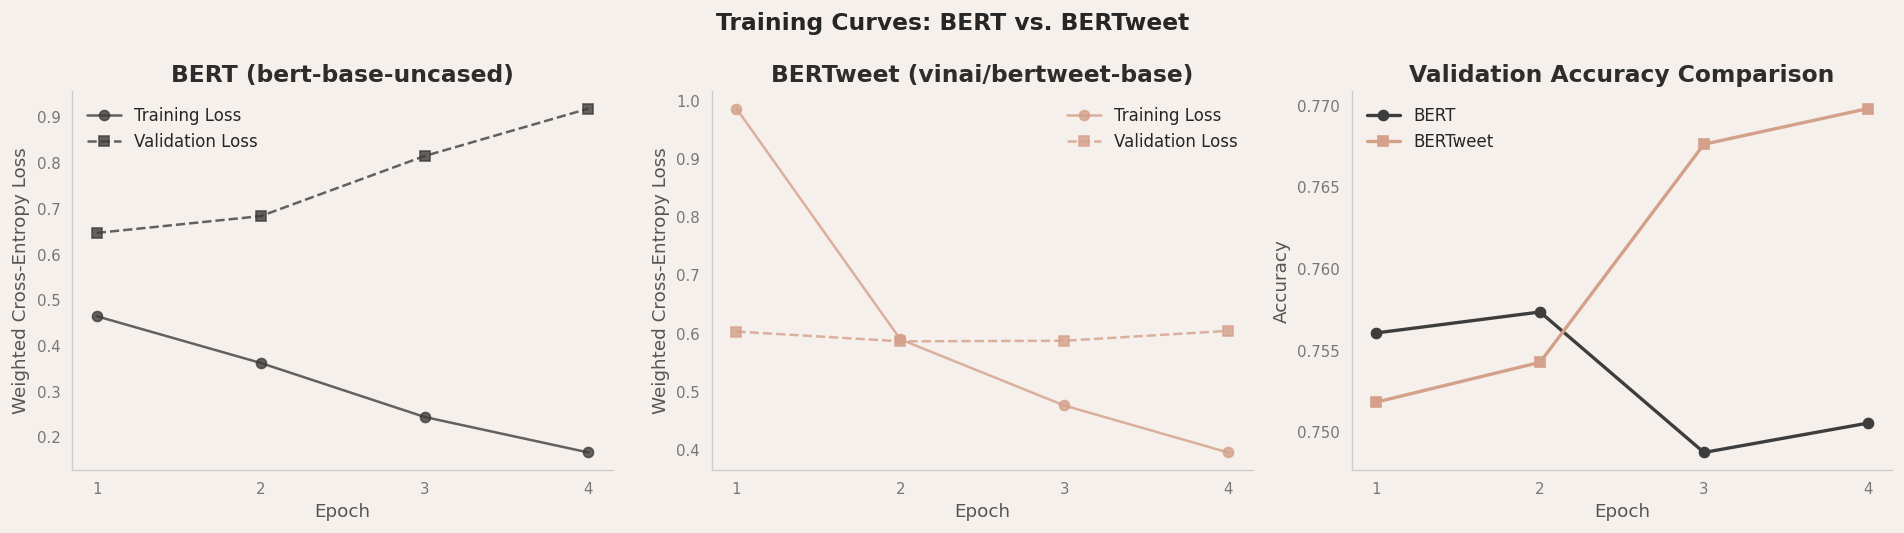

In [43]:
epochs_range_bert = range(1, len(epoch_train_losses) + 1)
epochs_range_btweet = range(1, len(btweet_train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# BERT loss curves
axes[0].plot(epochs_range_bert, epoch_train_losses, '-o', color=COLORS['bert'], label='Training Loss', alpha=0.8)
axes[0].plot(epochs_range_bert, epoch_val_losses, '--s', color=COLORS['bert'], label='Validation Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted Cross-Entropy Loss')
axes[0].set_title('BERT (bert-base-uncased)')
axes[0].legend()
axes[0].set_xticks(list(epochs_range_bert))

# BERTweet loss curves
axes[1].plot(epochs_range_btweet, btweet_train_losses, '-o', color=COLORS['bertweet'], label='Training Loss', alpha=0.8)
axes[1].plot(epochs_range_btweet, btweet_val_losses, '--s', color=COLORS['bertweet'], label='Validation Loss', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weighted Cross-Entropy Loss')
axes[1].set_title('BERTweet (vinai/bertweet-base)')
axes[1].legend()
axes[1].set_xticks(list(epochs_range_btweet))

# Validation accuracy comparison
axes[2].plot(epochs_range_bert, epoch_val_accuracies, '-o', color=COLORS['bert'], label='BERT', linewidth=2)
axes[2].plot(epochs_range_btweet, btweet_val_accuracies, '-s', color=COLORS['bertweet'], label='BERTweet', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy Comparison')
axes[2].legend()
max_epochs = max(len(epoch_val_accuracies), len(btweet_val_accuracies))
axes[2].set_xticks(range(1, max_epochs + 1))

plt.suptitle('Training Curves: BERT vs. BERTweet', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

---
## 15. Per-Class F1 Comparison

Instead of a single number, this shows how each model does on every category:

- **Where all models agree:** categories with distinctive vocabulary
- **Where BERT beats LogReg:** categories that need context
- **Where BERTweet beats BERT:** categories where tweet-specific language matters

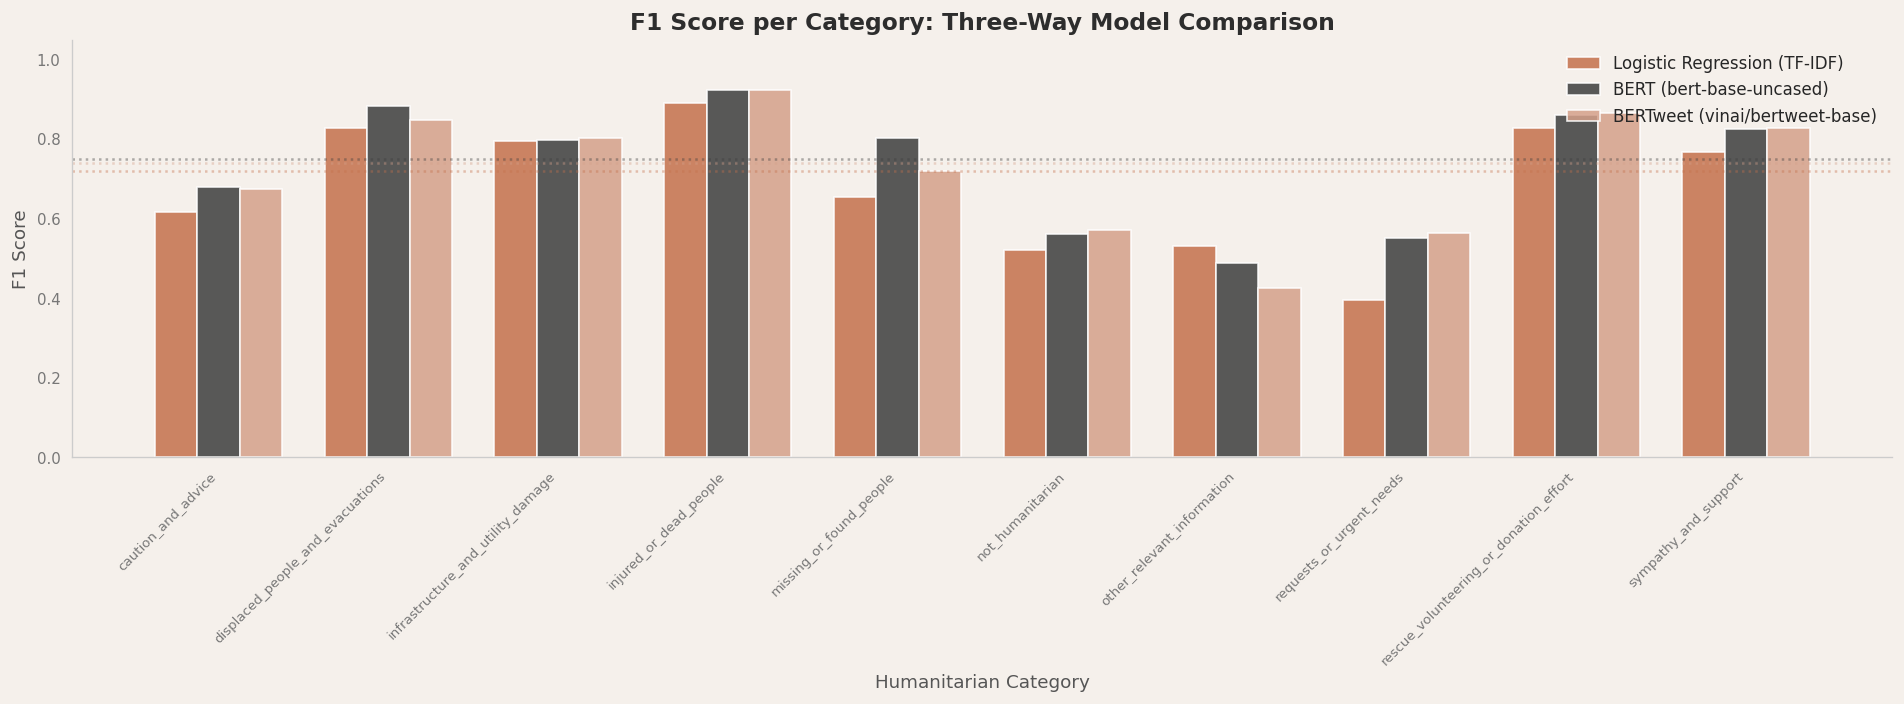

F1 per category (LogReg → BERT → BERTweet):
Category                                       LogReg    BERT  BERTweet   Best
--------------------------------------------------------------------------------
  caution_and_advice                            0.618   0.680     0.675   BERT
  displaced_people_and_evacuations              0.827   0.883     0.847   BERT
  infrastructure_and_utility_damage             0.796   0.797     0.803 BTweet
  injured_or_dead_people                        0.891   0.923     0.924 BTweet
  missing_or_found_people                       0.655   0.803     0.720   BERT
  not_humanitarian                              0.521   0.561     0.571 BTweet
  other_relevant_information                    0.531   0.490     0.426     LR
  requests_or_urgent_needs                      0.397   0.551     0.564 BTweet
  rescue_volunteering_or_donation_effort        0.828   0.860     0.866 BTweet
  sympathy_and_support                          0.767   0.825     0.828 BTweet

In [44]:
# Per-class F1 for all three models
logreg_f1_per_category = f1_score(y_test, logreg_predictions, average=None)
bert_f1_per_category = f1_score(bert_true_categories, bert_predictions, average=None)
bertweet_f1_per_category = f1_score(bertweet_true_categories, bertweet_predictions, average=None)

x = np.arange(num_categories)
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width, logreg_f1_per_category, width, label='Logistic Regression (TF-IDF)', color=COLORS['logreg'], alpha=0.85)
bars2 = ax.bar(x, bert_f1_per_category, width, label='BERT (bert-base-uncased)', color=COLORS['bert'], alpha=0.85)
bars3 = ax.bar(x + width, bertweet_f1_per_category, width, label='BERTweet (vinai/bertweet-base)', color=COLORS['bertweet'], alpha=0.85)

ax.set_xlabel('Humanitarian Category')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Category: Three-Way Model Comparison')
ax.set_xticks(x)
display_names = [name.replace('_', ' ').title() for name in category_names]
ax.set_xticklabels(display_names, rotation=45, ha='right', fontsize=8)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.05)
ax.axhline(y=logreg_weighted_f1, color=COLORS['logreg'], linestyle=':', alpha=0.4, label='_nolegend_')
ax.axhline(y=bert_weighted_f1, color=COLORS['bert'], linestyle=':', alpha=0.4, label='_nolegend_')
ax.axhline(y=bertweet_weighted_f1, color=COLORS['bertweet'], linestyle=':', alpha=0.4, label='_nolegend_')

plt.tight_layout()
plt.show()

# Print improvements
print("\nF1 per category (LogReg → BERT → BERTweet):")
print(f"{'Category':<45s} {'LogReg':>7s} {'BERT':>7s} {'BERTweet':>9s} {'Best':>6s}")
print("-" * 80)
for i, name in enumerate(category_names):
    lr, b, bt = logreg_f1_per_category[i], bert_f1_per_category[i], bertweet_f1_per_category[i]
    best = max(lr, b, bt)
    best_model = 'LR' if best == lr else ('BERT' if best == b else 'BTweet')
    print(f"  {name:<43s} {lr:>7.3f} {b:>7.3f} {bt:>9.3f} {best_model:>6s}")

---
## 16. Confusion Matrices

Side-by-side confusion matrices for all three models. The diagonal shows correct predictions. Off-diagonal entries show which categories each model confuses.

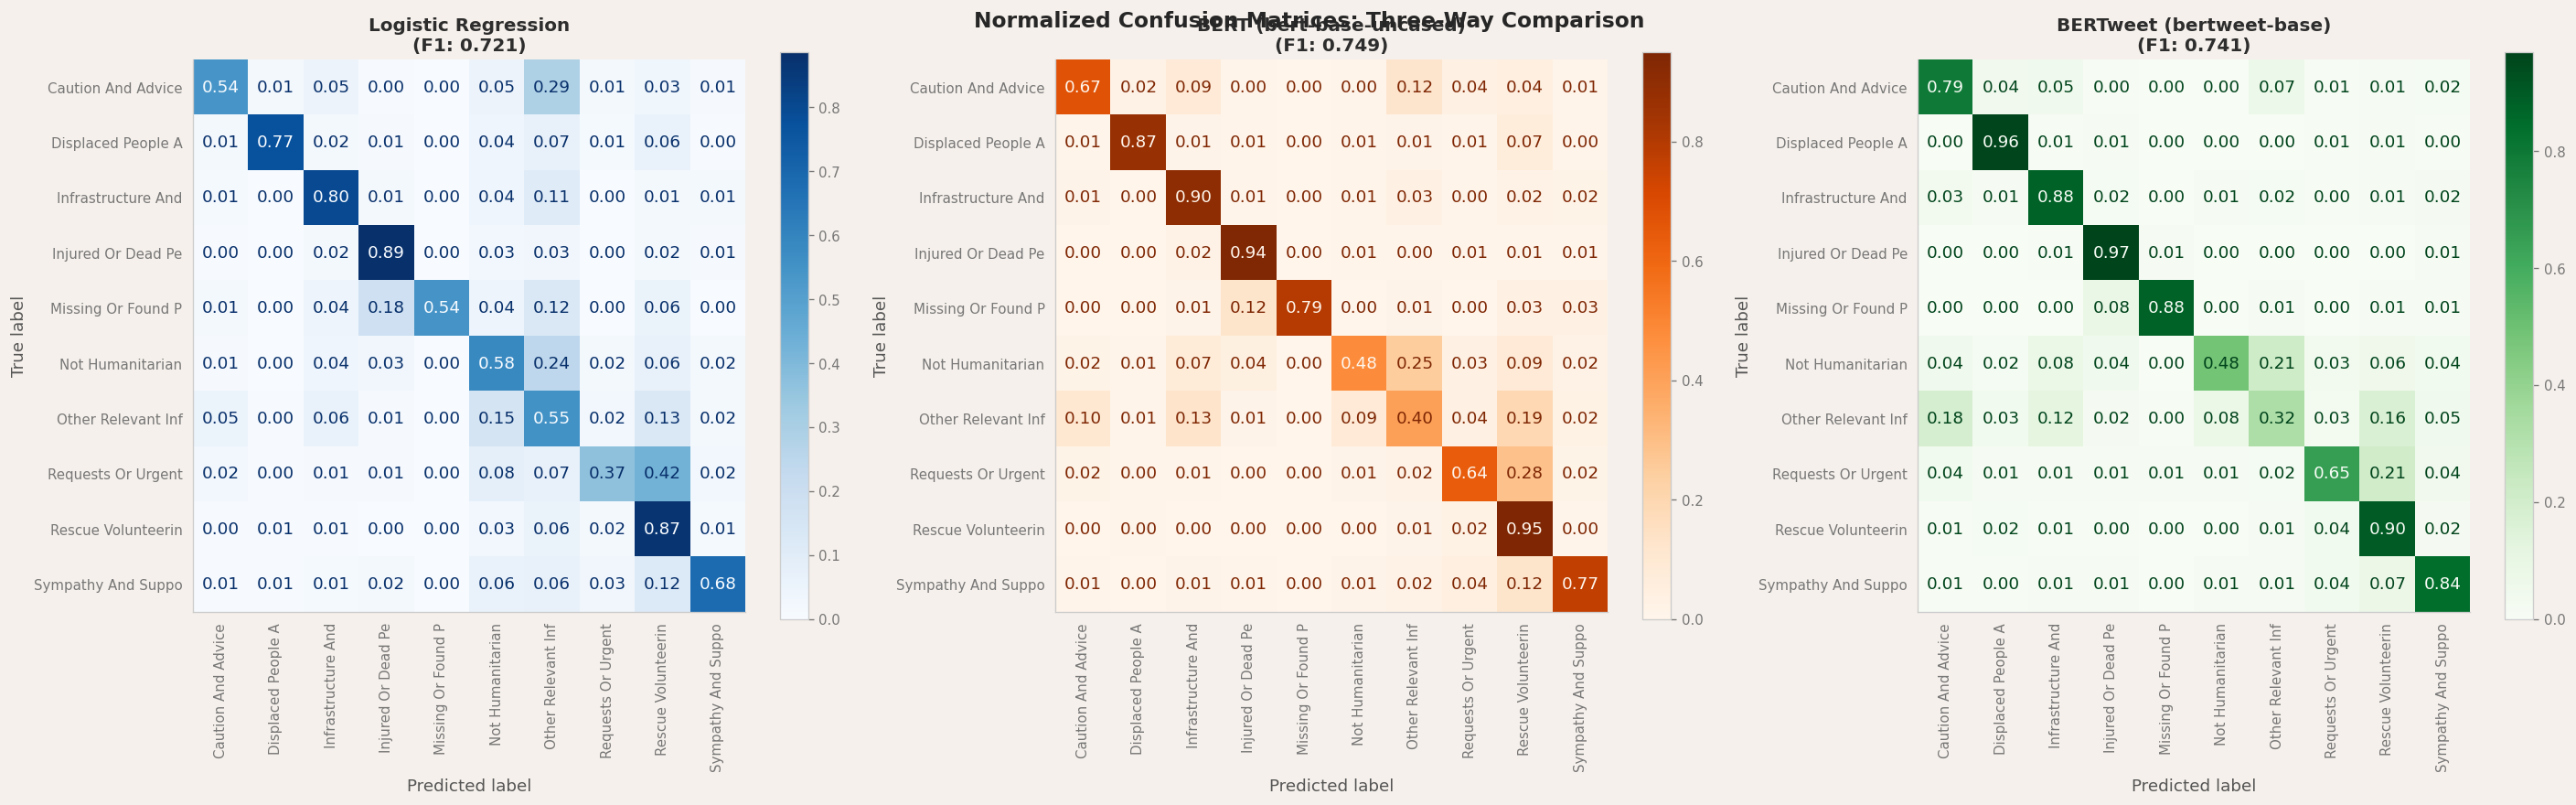

In [45]:
short_names = [name.replace('_', ' ').title()[:18] for name in category_names]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

# LogReg
cm_lr = confusion_matrix(y_test, logreg_predictions, normalize='true')
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=short_names)
disp_lr.plot(ax=ax1, cmap='Blues', values_format='.2f', xticks_rotation=90)
ax1.set_title(f'Logistic Regression\n(F1: {logreg_weighted_f1:.3f})', fontsize=12, fontweight='bold')

# BERT
cm_bert = confusion_matrix(bert_true_categories, bert_predictions, normalize='true')
disp_bert = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=short_names)
disp_bert.plot(ax=ax2, cmap='Oranges', values_format='.2f', xticks_rotation=90)
ax2.set_title(f'BERT (bert-base-uncased)\n(F1: {bert_weighted_f1:.3f})', fontsize=12, fontweight='bold')

# BERTweet
cm_btweet = confusion_matrix(bertweet_true_categories, bertweet_predictions, normalize='true')
disp_btweet = ConfusionMatrixDisplay(confusion_matrix=cm_btweet, display_labels=short_names)
disp_btweet.plot(ax=ax3, cmap='Greens', values_format='.2f', xticks_rotation=90)
ax3.set_title(f'BERTweet (bertweet-base)\n(F1: {bertweet_weighted_f1:.3f})', fontsize=12, fontweight='bold')

plt.suptitle('Normalized Confusion Matrices: Three-Way Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

---
## 17. Sample Misclassified Tweets

Looking at specific mistakes shows *why* models fail. We compare tweets where the simpler model got it wrong but the more advanced model got it right.

In [46]:
test_results_df = pd.DataFrame({
    'tweet_text': test_tweets_raw,
    'true_category': y_test,
    'logreg_pred': logreg_predictions,
    'bert_pred': bert_predictions,
    'bertweet_pred': bertweet_predictions
})

# Tweets BERT got wrong but BERTweet got right
bert_wrong_btweet_right = test_results_df[
    (test_results_df['bert_pred'] != test_results_df['true_category']) &
    (test_results_df['bertweet_pred'] == test_results_df['true_category'])
]

print(f"Tweets LogReg got wrong but BERT got right:     {((test_results_df['logreg_pred'] != test_results_df['true_category']) & (test_results_df['bert_pred'] == test_results_df['true_category'])).sum():,}")
print(f"Tweets BERT got wrong but BERTweet got right:   {len(bert_wrong_btweet_right):,}")
print(f"Tweets all three models got wrong:              {((test_results_df['logreg_pred'] != test_results_df['true_category']) & (test_results_df['bert_pred'] != test_results_df['true_category']) & (test_results_df['bertweet_pred'] != test_results_df['true_category'])).sum():,}")

print("\n--- Examples where BERTweet's tweet-specific knowledge helped ---\n")
for _, row in bert_wrong_btweet_right.head(5).iterrows():
    tweet = row['tweet_text']
    print(f"Tweet: \"{tweet[:120]}...\"" if len(tweet) > 120 else f"Tweet: \"{tweet}\"")
    print(f"  True:       {category_names[row['true_category']]}")
    print(f"  LogReg:     {category_names[row['logreg_pred']]}")
    print(f"  BERT:       {category_names[row['bert_pred']]} (wrong)")
    print(f"  BERTweet:   {category_names[row['bertweet_pred']]} (correct)")
    print()

# Tweets all models got wrong
all_wrong = test_results_df[
    (test_results_df['logreg_pred'] != test_results_df['true_category']) &
    (test_results_df['bert_pred'] != test_results_df['true_category']) &
    (test_results_df['bertweet_pred'] != test_results_df['true_category'])
]

print("\n--- Examples where all three models struggled (dataset ambiguity) ---\n")
for _, row in all_wrong.head(5).iterrows():
    tweet = row['tweet_text']
    print(f"Tweet: \"{tweet[:120]}...\"" if len(tweet) > 120 else f"Tweet: \"{tweet}\"")
    print(f"  True:       {category_names[row['true_category']]}")
    print(f"  LogReg:     {category_names[row['logreg_pred']]}")
    print(f"  BERT:       {category_names[row['bert_pred']]}")
    print(f"  BERTweet:   {category_names[row['bertweet_pred']]}")
    print()

Tweets LogReg got wrong but BERT got right:     1,729
Tweets BERT got wrong but BERTweet got right:   813
Tweets all three models got wrong:              2,044

--- Examples where BERTweet's tweet-specific knowledge helped ---

Tweet: "RT @PSYCHICTWINS: Huge Ecuador earthquake of 7.8 magnitude kills dozens. Prayers out, stay strong Ecuador."
  True:       sympathy_and_support
  LogReg:     injured_or_dead_people
  BERT:       injured_or_dead_people (wrong)
  BERTweet:   sympathy_and_support (correct)

Tweet: "@BTS_twt is sad ὢD but..It would be really important if you guys say the same for my country ecuador.. We had an earthqu..."
  True:       injured_or_dead_people
  LogReg:     sympathy_and_support
  BERT:       sympathy_and_support (wrong)
  BERTweet:   injured_or_dead_people (correct)

Tweet: "RT @shababaty: #EcuadorEarthquake First images of #Pedernales were 300Dead have been reported  via @teleamazonasec"
  True:       injured_or_dead_people
  LogReg:     other_relevant_informa

---
## 18. Final Comparison

Accuracy, Top-2 accuracy, weighted F1, training time, and parameter count for all three models. We also compare against the published benchmarks from the original HumAID paper (Alam et al., 2021).

In [47]:
# Final 3-way comparison table
logreg_num_params = logreg_model.coef_.size + logreg_model.intercept_.size

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Top-2 Accuracy', 'Weighted F1', 'Training Time (s)', 'Inference Time (s)', 'Parameters'],
    'Logistic Regression': [
        f"{logreg_accuracy:.4f}", f"{logreg_top2_accuracy:.4f}", f"{logreg_weighted_f1:.4f}",
        f"{logreg_train_time:.1f}", f"{logreg_infer_time:.2f}", f"{logreg_num_params:,}"
    ],
    'BERT': [
        f"{bert_accuracy:.4f}", f"{bert_top2_accuracy:.4f}", f"{bert_weighted_f1:.4f}",
        f"{bert_train_time:.1f}", f"{bert_infer_time:.2f}", f"{bert_total_params:,}"
    ],
    'BERTweet': [
        f"{bertweet_accuracy:.4f}", f"{bertweet_top2_accuracy:.4f}", f"{bertweet_weighted_f1:.4f}",
        f"{bertweet_train_time:.1f}", f"{bertweet_infer_time:.2f}", f"{bertweet_total_params:,}"
    ]
})

print("=" * 80)
print("          FINAL COMPARISON: LogReg vs. BERT vs. BERTweet (V3)")
print("=" * 80)
print(comparison.to_string(index=False))
print("=" * 80)

# Paper benchmarks
print("\n--- Comparison with published HumAID paper benchmarks (Alam et al., 2021) ---")
print(f"  Paper SVM (TF-IDF):          0.731 weighted F1")
print(f"  Our LogReg (TF-IDF):         {logreg_weighted_f1:.3f} weighted F1  {'(+)' if logreg_weighted_f1 > 0.731 else '(-)'}")
print(f"  Paper BERT:                  0.758 weighted F1")
print(f"  Our BERT:                    {bert_weighted_f1:.3f} weighted F1  {'(+)' if bert_weighted_f1 > 0.758 else '(-)'}")
print(f"  Paper RoBERTa (best):        0.760 weighted F1")
print(f"  Our BERTweet:                {bertweet_weighted_f1:.3f} weighted F1  {'(+)' if bertweet_weighted_f1 > 0.760 else '(-)'}")


          FINAL COMPARISON: LogReg vs. BERT vs. BERTweet (V3)
            Metric Logistic Regression        BERT    BERTweet
          Accuracy              0.7196      0.7613      0.7575
    Top-2 Accuracy              0.8854      0.9168      0.9185
       Weighted F1              0.7205      0.7494      0.7407
 Training Time (s)                29.5      5295.5      5439.0
Inference Time (s)                0.00       46.89       46.35
        Parameters             500,010 109,489,930 134,907,658

--- Comparison with published HumAID paper benchmarks (Alam et al., 2021) ---
  Paper SVM (TF-IDF):          0.731 weighted F1
  Our LogReg (TF-IDF):         0.721 weighted F1  (-)
  Paper BERT:                  0.758 weighted F1
  Our BERT:                    0.749 weighted F1  (-)
  Paper RoBERTa (best):        0.760 weighted F1
  Our BERTweet:                0.741 weighted F1  (-)

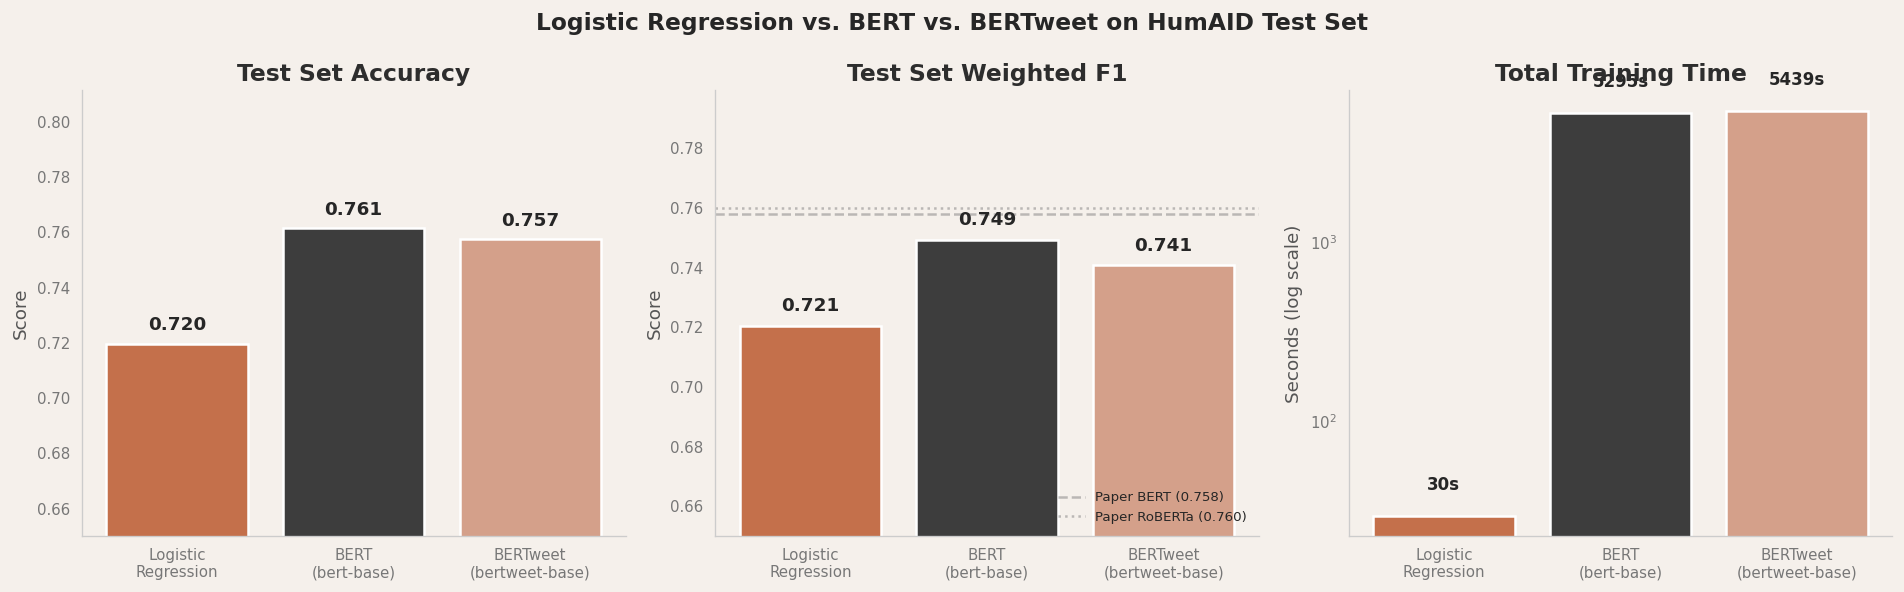

In [48]:
# Visual comparison — 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_labels = ['Logistic\nRegression', 'BERT\n(bert-base)', 'BERTweet\n(bertweet-base)']
colors = [COLORS['logreg'], COLORS['bert'], COLORS['bertweet']]

# Accuracy
vals = [logreg_accuracy, bert_accuracy, bertweet_accuracy]
bars = axes[0].bar(model_labels, vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Score')
axes[0].set_title('Test Set Accuracy')
axes[0].set_ylim(0.65, max(vals) + 0.05)
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

# Weighted F1
vals = [logreg_weighted_f1, bert_weighted_f1, bertweet_weighted_f1]
bars = axes[1].bar(model_labels, vals, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Score')
axes[1].set_title('Test Set Weighted F1')
axes[1].set_ylim(0.65, max(vals) + 0.05)
# Add paper benchmark line
axes[1].axhline(y=0.758, color='gray', linestyle='--', alpha=0.5, label='Paper BERT (0.758)')
axes[1].axhline(y=0.760, color='gray', linestyle=':', alpha=0.5, label='Paper RoBERTa (0.760)')
axes[1].legend(fontsize=8, loc='lower right')
for i, v in enumerate(vals):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

# Training time (log scale)
vals = [logreg_train_time, bert_train_time, bertweet_train_time]
bars = axes[2].bar(model_labels, vals, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_ylabel('Seconds (log scale)')
axes[2].set_title('Total Training Time')
axes[2].set_yscale('log')
for i, v in enumerate(vals):
    axes[2].text(i, v * 1.4, f'{v:.0f}s', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Logistic Regression vs. BERT vs. BERTweet on HumAID Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

---
## 18b. Cost vs. Performance Analysis

Bubble chart showing the tradeoff between training cost and performance. Bubble size represents parameter count. The log-scale x-axis shows the cost difference between traditional ML and transformers.

In [ ]:
# Cost vs Performance bubble chart
fig, ax = plt.subplots(figsize=(10, 6))

# Data
train_times_min = [logreg_train_time / 60, 5295.5 / 60, 5439.0 / 60]  # minutes
f1_pct = [logreg_weighted_f1 * 100, bert_weighted_f1 * 100, bertweet_weighted_f1 * 100]
param_counts = [logreg_model.coef_.size + logreg_model.intercept_.size, 109_489_930, 134_907_658]
colors_list = [COLORS['logreg'], COLORS['bert'], COLORS['bertweet']]
bubble_sizes = [80, 350, 420]  # scaled by parameter count

# Plot bubbles with subtle glow
for x, y, s, c in zip(train_times_min, f1_pct, bubble_sizes, colors_list):
    ax.scatter(x, y, s=s*1.8, c=c, alpha=0.15, edgecolors='none', zorder=2)
    ax.scatter(x, y, s=s, c=c, alpha=0.9, edgecolors='white', linewidth=1.5, zorder=3)

# Model labels
ax.annotate('Logistic\nRegression', (train_times_min[0], f1_pct[0]), xytext=(20, 18),
            textcoords='offset points', fontsize=10, fontweight='bold', color=COLORS['logreg'], va='center')
ax.annotate('Fine-tuned\nBERT', (train_times_min[1], f1_pct[1]), xytext=(-80, 20),
            textcoords='offset points', fontsize=10, fontweight='bold', color=COLORS['bert'], va='center')
ax.annotate('BERTweet', (train_times_min[2], f1_pct[2]), xytext=(-75, -20),
            textcoords='offset points', fontsize=10, fontweight='bold', color='#6B9E8E', va='center')

# Parameter count annotations
ax.annotate(f'{param_counts[0]//1000}K params', (train_times_min[0], f1_pct[0]), xytext=(20, -10),
            textcoords='offset points', fontsize=8, color='#999999', style='italic')
ax.annotate('110M params', (train_times_min[1], f1_pct[1]), xytext=(-80, 5),
            textcoords='offset points', fontsize=8, color='#999999', style='italic')
ax.annotate('135M params', (train_times_min[2], f1_pct[2]), xytext=(-75, -33),
            textcoords='offset points', fontsize=8, color='#999999', style='italic')

# Cost arrow spanning LogReg to BERT
ax.annotate('',
            xy=(train_times_min[1], f1_pct[0] - 0.75), xytext=(train_times_min[0], f1_pct[0] - 0.75),
            arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.5, ls='--'))
mid_x = np.sqrt(train_times_min[0] * train_times_min[1])  # geometric mean for log scale
time_ratio = train_times_min[1] / train_times_min[0]
f1_diff = f1_pct[1] - f1_pct[0]
ax.text(mid_x, f1_pct[0] - 0.3, f'{time_ratio:.0f}x more training time for +{f1_diff:.1f}% wF1',
        ha='center', fontsize=9, color=COLORS['danger'], style='italic')

# Formatting
ax.set_xscale('log')
ax.set_xlabel('Training Time (minutes, log scale)')
ax.set_ylabel('Performance (Weighted F1 %)')
ax.set_title('Cost vs. Performance: Massive Cost, Marginal Gain')
ax.set_ylim(f1_pct[0] - 2, f1_pct[1] + 3)
ax.set_xlim(0.3, 150)
ax.yaxis.grid(True, alpha=0.3, color='#D8E0DC')
ax.xaxis.grid(False)
sns.despine()
plt.tight_layout()
plt.show()
